# Reproduction Fig. 4 — Bernton, Jacob, Gerber & Robert (2019)

**Modèle** (Section 4) :
- Données observées : $y_i \overset{iid}{\sim} \mathcal{N}(0,\, 4 I_d)$ — fixées, vrai paramètre $\theta^* = 4$
- Données simulées  : $z_{\theta,i} \overset{iid}{\sim} \mathcal{N}(0,\, \theta I_d)$, $\theta \in [0.1, 9]$
- $n = 500$, $d \in \{2, 3, 4, 5\}$, distance d'ordre $p = 2$

**3 distances tracées en fonction de $\theta$** :
| Distance | Algorithme | Complexité |
|---|---|---|
| $W_2$ (Wasserstein) | LSA / Hongrois optimal | $O(n^3)$ |
| $H_2$ (Hilbert) | Tri sur courbe de Hilbert CGAL `hilbert_sort_nd` | $O(n \log n)$ |
| $S_2$ (Swapping) | Hilbert + sweeps greedy Puccetti (2017) | $O(n^2)$/sweep |

**Ce qu'on vérifie** : les 3 courbes sont-elles minimisées au même $\theta^* = 4$ ?
Si oui → $H_2$ et $S_2$ sont des substituts valides à $W_2$ pour le seuil $\varepsilon$ en ABC.
La dégradation de $H_2$ quand $d$ croît montre l'intérêt du Swapping en haute dimension.


In [1]:

import sys, pathlib, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import numba

_CORE = pathlib.Path('/Users/antoineluciano/Documents/Recherche/permABC/permabc/core')
if str(_CORE) not in sys.path:
    sys.path.insert(0, str(_CORE))

import cgal_hilbert
print('cgal_hilbert:', cgal_hilbert.__file__)
print('hilbert_sort_nd disponible:', hasattr(cgal_hilbert, 'hilbert_sort_nd'))

# ── Paramètres Fig. 4 (fidèles au papier) ────────────────────────────────
N          = 500
D_LIST     = [2, 3, 4, 5, 10,50, 100, 150]          # exactement les 4 dimensions du papier
THETA_GRID = np.linspace(0.1, 9.0, 100)
THETA_STAR = 4.0                    # vrai paramètre (y ~ N(0, θ* I_d))
P          = 2

rng = np.random.default_rng(0)


cgal_hilbert: /Users/antoineluciano/Documents/Recherche/permABC/permabc/core/cgal_hilbert.cpython-39-darwin.so
hilbert_sort_nd disponible: True


In [2]:

# ==========================================================================
# Distances: Wasserstein (LSA), Hilbert, Swapping (Numba)
# ==========================================================================

# ==========================================================================
# Distances : Wasserstein (LSA), Hilbert CGAL nD, Swapping (Numba)
# ==========================================================================

def build_cost(y, z):
    """Matrice de coût ||y_i - z_j||² (shape K×K)."""
    diff = y[:, None, :] - z[None, :, :]
    return np.sum(diff**2, axis=-1)


def wasserstein_W2(y, z):
    """W_2 exact via scipy linear_sum_assignment."""
    cost = build_cost(y, z)
    r, c = linear_sum_assignment(cost)
    return float(np.sqrt(cost[r, c].mean()))


def _rank_normalize(pts):
    """Convertit chaque colonne en rangs fractionnaires ∈ [0,1].
    Améliore la qualité du tri CGAL (subdivision médiane sur données uniformes).
    """
    K, d = pts.shape
    out = np.empty((K, d), dtype=np.float64)
    denom = max(K - 1, 1)
    for j in range(d):
        out[:, j] = np.argsort(np.argsort(pts[:, j])) / denom
    return np.ascontiguousarray(out)


def hilbert_order_cgal(points, policy='median'):
    """sorted_idx[rank] = original_idx via CGAL::hilbert_sort_nd (d-dimensionnel).

    On rank-normalise les points avant de passer à CGAL pour que la
    subdivision médiane soit équilibrée quelle que soit la distribution.
    """
    sorted_idx = cgal_hilbert.hilbert_sort_nd(_rank_normalize(points), policy)
    return np.asarray(sorted_idx, dtype=np.int64)


def hilbert_H2(y, z):
    """H_2 : apparie y et z par rang Hilbert commun, calcule la distance."""
    oy = hilbert_order_cgal(y)   # oy[rank] = idx dans y
    oz = hilbert_order_cgal(z)   # oz[rank] = idx dans z
    diff = y[oy] - z[oz]         # paires (rank 0,1,...,K-1)
    return float(np.sqrt(np.mean(np.sum(diff**2, axis=-1))))


def hilbert_sigma(y, z):
    """Permutation σ de Hilbert : σ[i] = j tel que rank_Hilbert(y_i) = rank_Hilbert(z_j)."""
    oy = hilbert_order_cgal(y)
    oz = hilbert_order_cgal(z)
    rank_y = np.argsort(oy)      # rank_y[original_y_idx] = rank
    return oz[rank_y]            # σ[i] = z-idx qui a le même rang Hilbert que y[i]


def dist_from_sigma(cost, sigma):
    return float(np.sqrt(cost[np.arange(cost.shape[0]), sigma].mean()))


@numba.njit
def _swap_greedy_numba(cost, sigma, max_sweeps):
    """Greedy swapping (Puccetti 2017) : réduit le coût par échanges successifs."""
    K = len(sigma)
    for sweep in range(max_sweeps):
        changed = False
        for i in range(K):
            si = sigma[i]
            for j in range(i + 1, K):
                sj = sigma[j]
                if cost[i, si] + cost[j, sj] > cost[i, sj] + cost[j, si]:
                    sigma[i] = sj
                    sigma[j] = si
                    si = sigma[i]
                    changed = True
        if not changed:
            return sigma, sweep + 1
    return sigma, max_sweeps

_swap_greedy_numba(np.ones((3, 3), np.float64), np.array([0, 1, 2], np.int64), 5)  # warmup


def swapping_S2(y, z, max_sweeps=50):
    """S_2 : Hilbert + sweeps greedy.  Vérifie W_2 ≤ S_2 ≤ H_2."""
    cost  = build_cost(y, z)
    sig0  = hilbert_sigma(y, z).astype(np.int64)
    sig, sweeps = _swap_greedy_numba(cost, sig0, max_sweeps)
    return dist_from_sigma(cost, sig), int(sweeps)

print('Distances prêtes (Wasserstein, Hilbert CGAL nD, Swapping Numba)')


Distances prêtes (Wasserstein, Hilbert CGAL nD, Swapping Numba)


In [3]:

# ==========================================================================
# Calcul Fig. 4 : distances vs θ pour d ∈ {2,3,4,5}
# ==========================================================================

# y fixé (une seule réalisation par dimension), z_θ varie le long de la grille
# y ~ N(0, θ* I_d),  z_θ ~ N(0, θ I_d)
Y_by_d = {d: rng.normal(0.0, np.sqrt(THETA_STAR), size=(N, d)) for d in D_LIST}

curves = {d: {'W': [], 'H': [], 'S': [], 'sweeps': []} for d in D_LIST}
times  = {'W': [], 'H': [], 'S': []}

for d in D_LIST:
    y = Y_by_d[d]
    for theta in THETA_GRID:
        z = rng.normal(0.0, np.sqrt(theta), size=(N, d))

        t0 = time.perf_counter(); W         = wasserstein_W2(y, z);   times['W'].append(time.perf_counter() - t0)
        t0 = time.perf_counter(); H         = hilbert_H2(y, z);       times['H'].append(time.perf_counter() - t0)
        t0 = time.perf_counter(); S, sweeps = swapping_S2(y, z);      times['S'].append(time.perf_counter() - t0)

        curves[d]['W'].append(W)
        curves[d]['H'].append(H)
        curves[d]['S'].append(S)
        curves[d]['sweeps'].append(sweeps)

    print(f'd={d} ✓')

print('\nTemps médian par évaluation (toutes dimensions) :')
for k, label in [('H','Hilbert'), ('S','Swapping'), ('W','Wasserstein')]:
    print(f'  {label:12s}: {np.median(times[k])*1e3:.2f} ms')


d=2 ✓
d=3 ✓
d=4 ✓
d=5 ✓
d=10 ✓
d=50 ✓
d=100 ✓
d=150 ✓

Temps médian par évaluation (toutes dimensions) :
  Hilbert     : 3.73 ms
  Swapping    : 37.36 ms
  Wasserstein : 91.47 ms


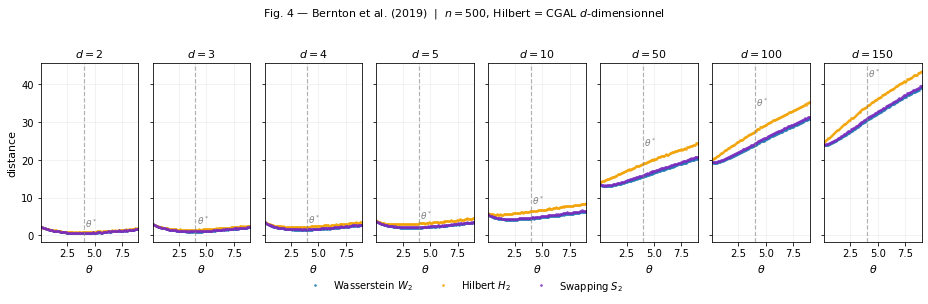

Sweeps médians par dimension :
  d=2: sweeps=6.0  |  S/W=1.056  H/W=1.469
  d=3: sweeps=6.0  |  S/W=1.077  H/W=1.500
  d=4: sweeps=6.0  |  S/W=1.083  H/W=1.580
  d=5: sweeps=7.0  |  S/W=1.086  H/W=1.591
  d=10: sweeps=7.0  |  S/W=1.060  H/W=1.446
  d=50: sweeps=8.0  |  S/W=1.026  H/W=1.211
  d=100: sweeps=7.5  |  S/W=1.019  H/W=1.153
  d=150: sweeps=8.0  |  S/W=1.015  H/W=1.123


In [4]:

# ==========================================================================
# Plot: reproduction (style proche Fig.4)
# ==========================================================================

# ==========================================================================
# Figure 4 (reproduction)
# ==========================================================================

colors = {'W': '#1f77b4', 'H': '#f2a100', 'S': '#7b2cbf'}
labels = {'W': 'Wasserstein $W_2$', 'H': 'Hilbert $H_2$', 'S': 'Swapping $S_2$'}

fig, axes = plt.subplots(1, len(D_LIST), figsize=(13, 3.8), sharey=True)
ms = 3.5

for ax, d in zip(axes, D_LIST):
    for key in ['W', 'H', 'S']:
        ax.plot(THETA_GRID, curves[d][key], '.', ms=ms,
                color=colors[key], label=labels[key], alpha=0.7)

    # Ligne verticale θ* = 4 (vrai paramètre)
    ax.axvline(THETA_STAR, color='gray', lw=1.2, ls='--', alpha=0.6)
    ax.text(THETA_STAR + 0.1, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 1 else 4.1,
            r'$\theta^*$', color='gray', fontsize=9)

    ax.set_title(f'$d = {d}$', fontsize=11)
    ax.set_xlabel(r'$\theta$', fontsize=11)
    ax.set_xlim(0.1, 9.0)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('distance', fontsize=11)

handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)

fig.suptitle('Fig. 4 — Bernton et al. (2019)  |  $n=500$, Hilbert = CGAL $d$-dimensionnel',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig4_reproduction.pdf', bbox_inches='tight')
plt.show()

# ── Rapport numériques ────────────────────────────────────────────────────
print('Sweeps médians par dimension :')
for d in D_LIST:
    sw = np.median(curves[d]['sweeps'])
    # ratio S/W et H/W à θ=θ* (indice le plus proche)
    idx_star = np.argmin(np.abs(THETA_GRID - THETA_STAR))
    sw_val = curves[d]['S'][idx_star]
    hw_val = curves[d]['H'][idx_star]
    ww_val = curves[d]['W'][idx_star]
    print(f'  d={d}: sweeps={sw:.1f}  |  S/W={sw_val/ww_val:.3f}  H/W={hw_val/ww_val:.3f}')


## Notes

**Fidélité au papier**
- Hilbert = `CGAL::hilbert_sort_nd` en dimension native ($d = 2,3,4,5$), avec rank-normalisation → conforme à Bernton et al.
- Swapping = algorithme exact de Puccetti (2017), initialisé par $\sigma_{\text{Hilbert}}$.
- $n=500$, $d \in \{2,3,4,5\}$ — identiques au papier.

**Timings attendus** (papier, machine ~2016) :
| Distance | Temps / évaluation |
|---|---|
| $H_2$ Hilbert | $\sim 2 \times 10^{-3}$ s |
| $S_2$ Swapping | $\sim 3 \times 10^{-2}$ s |
| $W_2$ Wasserstein | $\sim 2 \times 10^{-1}$ s |

**Lecture des ratios à $\theta^*=4$** :
- $S_2/W_2 \approx 1$ → Swapping est une excellente approximation de Wasserstein.
- $H_2/W_2$ croît avec $d$ → Hilbert se dégrade plus vite que Swapping en haute dimension.
- Les trois courbes atteignent leur minimum à $\theta^* = 4$ → toutes trois sont valides comme seuil ABC.


---
## Analyse sur grille (K, d) — Hamming et temps

Pour chaque combinaison (K, d) on génère `N_THETA_KD` paires (y, z_θ) avec θ aléatoire dans [0.1, 9].
On calcule les 3 permutations : σ\* (LSA), σ_H (Hilbert CGAL), σ_S (Swap initialisé par Hilbert).

**Métriques stockées par (K, d) :**
- `time_W`, `time_H`, `time_S` — temps médian par évaluation (ms)
- `hamming_H` — Hamming(σ_H, σ\*) : fraction de positions mal assignées par Hilbert
- `hamming_S` — Hamming(σ_S, σ\*) : fraction de positions mal assignées par Swapping
- `ratio_H`, `ratio_S` — rapport de distance H/W et S/W

**Lectures attendues :**
- Hamming ↑ avec d (Hilbert se dégrade géométriquement)
- Hamming ↓ avec K (loi des grands nombres — les rangs Hilbert convergent)
- Swap corrige une partie du Hamming de Hilbert, coûtant O(K²) sweeps

In [5]:
# ==========================================================================
# Calcul grille (K, d) — Hamming + temps
# ==========================================================================

K_LIST      = [50, 100, 200, 500]      # tailles de nuage à tester
D_LIST_KD   = [2, 3, 4, 5]            # dimensions (identiques au papier)
N_THETA_KD  = 30                       # évaluations (θ aléatoires) par (K,d)

def hamming(a, b):
    """Fraction de positions où a[i] ≠ b[i]."""
    return float(np.mean(a != b))

# ── Grille ────────────────────────────────────────────────────────────────
# Timings définis de façon cohérente :
#   time_W = build_cost + LSA                    (O(K²d + K³))
#   time_H = hilbert_sigma + H distance          (O(Kd log K))  — pas de matrice K×K !
#   time_S = hilbert_sigma + build_cost + swap   (O(Kd log K + K²d + K² sweeps))
#   → par construction time_S ≥ time_H toujours

grid = {K: {d: {'time_W':[], 'time_H':[], 'time_S':[],
                'hamming_H':[], 'hamming_S':[],
                'ratio_H':[], 'ratio_S':[], 'sweeps':[]}
            for d in D_LIST_KD}
        for K in K_LIST}

rng_kd = np.random.default_rng(1234)
theta_samples = rng_kd.uniform(0.5, 8.0, N_THETA_KD)

for K in K_LIST:
    for d in D_LIST_KD:
        y = rng_kd.normal(0.0, np.sqrt(THETA_STAR), (K, d))
        for theta in theta_samples:
            z = rng_kd.normal(0.0, np.sqrt(theta), (K, d))

            # ── LSA : build_cost + linear_sum_assignment ──────────────────
            t0 = time.perf_counter()
            cost = build_cost(y, z)
            _, sig_W = linear_sum_assignment(cost)
            sig_W = sig_W.astype(np.int64)
            W = float(np.sqrt(cost[np.arange(K), sig_W].mean()))
            grid[K][d]['time_W'].append(time.perf_counter() - t0)

            # ── Hilbert : sort + appariement par rang (sans matrice K×K) ──
            # H_2 = sqrt(mean ||y[oy_i] - z[oz_i]||²) — O(Kd log K)
            t0 = time.perf_counter()
            oy = hilbert_order_cgal(y)
            oz = hilbert_order_cgal(z)
            diff_H = y[oy] - z[oz]
            H = float(np.sqrt(np.mean(np.sum(diff_H**2, axis=-1))))
            # σ_H[i] = oz[rank_y[i]]  (pour Hamming vs σ*)
            rank_y = np.argsort(oy)
            sig_H  = oz[rank_y]
            grid[K][d]['time_H'].append(time.perf_counter() - t0)

            # ── Swapping : hilbert_sigma + build_cost + swap ───────────────
            # Pipeline complet depuis zéro (comme dans le papier)
            t0 = time.perf_counter()
            sig_H2  = hilbert_sigma(y, z).astype(np.int64)   # = sig_H, recomputed
            cost_s  = build_cost(y, z)
            sig_S, sw = _swap_greedy_numba(cost_s, sig_H2.copy(), 50)
            S = float(np.sqrt(cost_s[np.arange(K), sig_S].mean()))
            grid[K][d]['time_S'].append(time.perf_counter() - t0)

            # ── Métriques ────────────────────────────────────────────────
            grid[K][d]['hamming_H'].append(hamming(sig_H, sig_W))
            grid[K][d]['hamming_S'].append(hamming(sig_S, sig_W))
            grid[K][d]['ratio_H'].append(H / W if W > 0 else 1.0)
            grid[K][d]['ratio_S'].append(S / W if W > 0 else 1.0)
            grid[K][d]['sweeps'].append(sw)

        print(f'  K={K:4d}, d={d} ✓')

# ── Agréger (médiane) ─────────────────────────────────────────────────────
import numpy as np

def med(K, d, key):
    return float(np.median(grid[K][d][key]))

print('\n── Résumé (médiane) ──')
print(f"{'K':>6} {'d':>3}  {'tW(ms)':>8} {'tH(ms)':>8} {'tS(ms)':>8}  {'Ham_H':>7} {'Ham_S':>7}  {'H/W':>6} {'S/W':>6}")
for K in K_LIST:
    for d in D_LIST_KD:
        print(f"{K:6d} {d:3d}  "
              f"{med(K,d,'time_W')*1e3:8.2f} {med(K,d,'time_H')*1e3:8.2f} {med(K,d,'time_S')*1e3:8.2f}  "
              f"{med(K,d,'hamming_H'):7.3f} {med(K,d,'hamming_S'):7.3f}  "
              f"{med(K,d,'ratio_H'):6.3f} {med(K,d,'ratio_S'):6.3f}")

  K=  50, d=2 ✓
  K=  50, d=3 ✓
  K=  50, d=4 ✓
  K=  50, d=5 ✓
  K= 100, d=2 ✓
  K= 100, d=3 ✓
  K= 100, d=4 ✓
  K= 100, d=5 ✓
  K= 200, d=2 ✓
  K= 200, d=3 ✓
  K= 200, d=4 ✓
  K= 200, d=5 ✓
  K= 500, d=2 ✓
  K= 500, d=3 ✓
  K= 500, d=4 ✓
  K= 500, d=5 ✓

── Résumé (médiane) ──
     K   d    tW(ms)   tH(ms)   tS(ms)    Ham_H   Ham_S     H/W    S/W
    50   2      0.29     0.19     0.32    0.750   0.390   1.177  1.030
    50   3      0.30     0.22     0.34    0.820   0.410   1.325  1.029
    50   4      0.29     0.24     0.37    0.820   0.470   1.298  1.045
    50   5      0.29     0.25     0.39    0.850   0.460   1.289  1.034
   100   2      1.14     0.35     0.83    0.800   0.465   1.212  1.037
   100   3      1.27     0.44     1.02    0.825   0.470   1.356  1.042
   100   4      2.12     0.66     1.67    0.855   0.475   1.356  1.045
   100   5      2.43     0.95     2.32    0.855   0.550   1.315  1.045
   200   2      5.82     0.66     2.87    0.800   0.545   1.212  1.033
   200   3

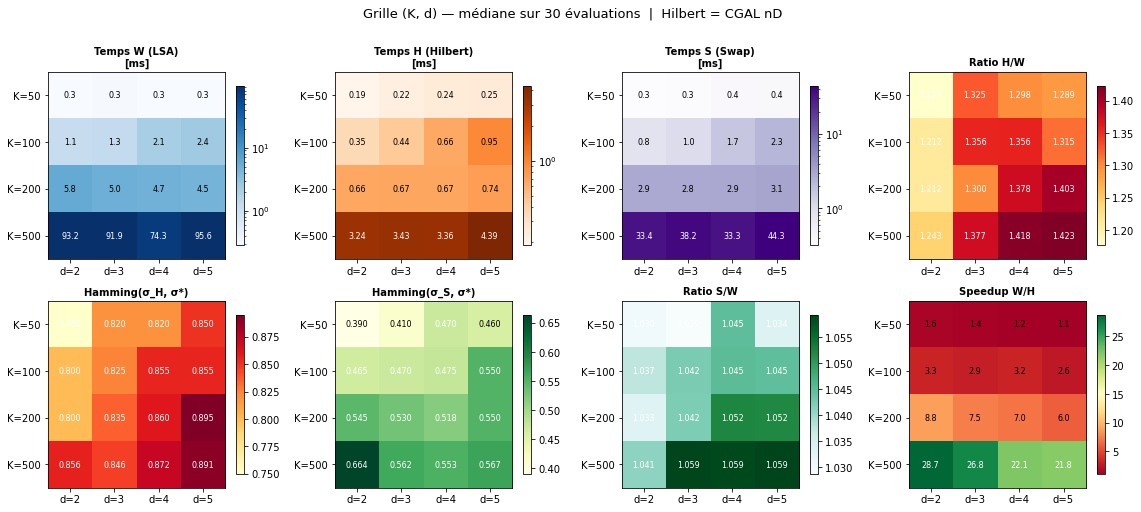

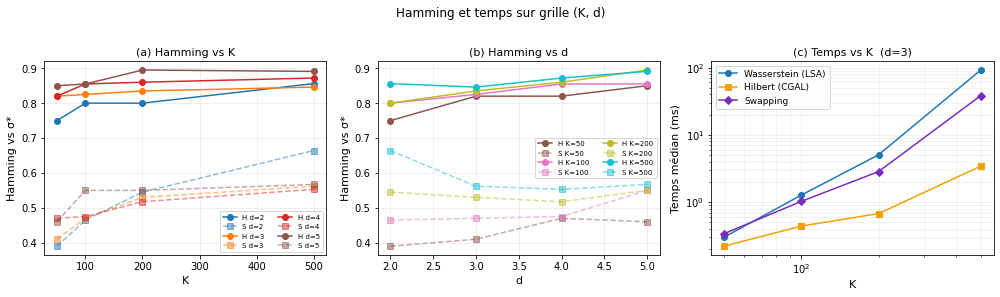

In [6]:
# ==========================================================================
# Figure — heatmaps (K × d) et courbes
# ==========================================================================
import matplotlib.colors as mcolors

Ks = K_LIST
Ds = D_LIST_KD

def make_mat(key, transform=lambda x: x):
    """Matrice (len(Ks) × len(Ds)) de la médiane d'une métrique."""
    return np.array([[transform(med(K, d, key)) for d in Ds] for K in Ks])

mat_tW  = make_mat('time_W', lambda x: x*1e3)
mat_tH  = make_mat('time_H', lambda x: x*1e3)
mat_tS  = make_mat('time_S', lambda x: x*1e3)
mat_hH  = make_mat('hamming_H')
mat_hS  = make_mat('hamming_S')
mat_rH  = make_mat('ratio_H')
mat_rS  = make_mat('ratio_S')

# ── Layout : 2 lignes, 4 colonnes ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

specs = [
    # (matrice, titre, colormap, fmt, log?)
    (mat_tW,  'Temps W (LSA)\n[ms]',         'Blues',    '.1f', True),
    (mat_tH,  'Temps H (Hilbert)\n[ms]',      'Oranges',  '.2f', True),
    (mat_tS,  'Temps S (Swap)\n[ms]',         'Purples',  '.1f', True),
    (mat_rH,  'Ratio H/W',                    'YlOrRd',   '.3f', False),
    (mat_hH,  'Hamming(σ_H, σ*)',              'YlOrRd',   '.3f', False),
    (mat_hS,  'Hamming(σ_S, σ*)',              'YlGn',     '.3f', False),
    (mat_rS,  'Ratio S/W',                    'BuGn',     '.3f', False),
    (mat_tW / (mat_tH + 1e-9), 'Speedup W/H',  'RdYlGn',   '.1f', False),
]

for ax, (mat, title, cmap, fmt, log) in zip(axes.flat, specs):
    norm = mcolors.LogNorm(vmin=mat.min()+1e-9, vmax=mat.max()) if log else None
    im   = ax.imshow(mat, cmap=cmap, aspect='auto', norm=norm,
                     vmin=(None if log else mat.min()),
                     vmax=(None if log else mat.max()))
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(len(Ds))); ax.set_xticklabels([f'd={d}' for d in Ds])
    ax.set_yticks(range(len(Ks))); ax.set_yticklabels([f'K={K}' for K in Ks])
    ax.set_title(title, fontsize=10, fontweight='bold')
    # annoter les valeurs
    for i in range(len(Ks)):
        for j in range(len(Ds)):
            v = mat[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    fontsize=8, color='black' if v < mat.max()*0.7 else 'white')

fig.suptitle(f'Grille (K, d) — médiane sur {N_THETA_KD} évaluations  |  Hilbert = CGAL nD',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_kd_grid.pdf', bbox_inches='tight')
plt.show()

# ── Courbes : Hamming vs K (fixe d) et Hamming vs d (fixe K) ─────────────
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

colors_d = plt.cm.tab10(np.linspace(0, 0.5, len(Ds)))
colors_K = plt.cm.tab10(np.linspace(0.5, 1.0, len(Ks)))

# (a) Hamming vs K pour chaque d
for j, d in enumerate(Ds):
    hH = [med(K, d, 'hamming_H') for K in Ks]
    hS = [med(K, d, 'hamming_S') for K in Ks]
    ax1.plot(Ks, hH, 'o-',  color=colors_d[j], label=f'H d={d}')
    ax1.plot(Ks, hS, 's--', color=colors_d[j], alpha=0.5, label=f'S d={d}')
ax1.set_xlabel('K', fontsize=11); ax1.set_ylabel('Hamming vs σ*', fontsize=11)
ax1.set_title('(a) Hamming vs K', fontsize=11)
ax1.legend(fontsize=7, ncol=2); ax1.grid(True, alpha=0.25)

# (b) Hamming vs d pour chaque K
for i, K in enumerate(Ks):
    hH = [med(K, d, 'hamming_H') for d in Ds]
    hS = [med(K, d, 'hamming_S') for d in Ds]
    ax2.plot(Ds, hH, 'o-',  color=colors_K[i], label=f'H K={K}')
    ax2.plot(Ds, hS, 's--', color=colors_K[i], alpha=0.5, label=f'S K={K}')
ax2.set_xlabel('d', fontsize=11); ax2.set_ylabel('Hamming vs σ*', fontsize=11)
ax2.set_title('(b) Hamming vs d', fontsize=11)
ax2.legend(fontsize=7, ncol=2); ax2.grid(True, alpha=0.25)

# (c) Temps médian vs K pour chaque méthode (d=3 fixé)
d_fixed = 3
tW = [med(K, d_fixed, 'time_W')*1e3 for K in Ks]
tH = [med(K, d_fixed, 'time_H')*1e3 for K in Ks]
tS = [med(K, d_fixed, 'time_S')*1e3 for K in Ks]
ax3.loglog(Ks, tW, 'o-',  color='#1f77b4', label='Wasserstein (LSA)')
ax3.loglog(Ks, tH, 's-',  color='#f2a100', label='Hilbert (CGAL)')
ax3.loglog(Ks, tS, 'D-',  color='#7b2cbf', label='Swapping')
ax3.set_xlabel('K', fontsize=11); ax3.set_ylabel('Temps médian (ms)', fontsize=11)
ax3.set_title(f'(c) Temps vs K  (d={d_fixed})', fontsize=11)
ax3.legend(fontsize=9); ax3.grid(True, which='both', alpha=0.2)

fig2.suptitle('Hamming et temps sur grille (K, d)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_kd_curves.pdf', bbox_inches='tight')
plt.show()

---
## Section 3 — Sinkhorn Distance (Cuturi 2013, Bernton et al. §2.3.4)

**Définition** (papier, eq. 5) :

$$\gamma^\zeta = \arg\min_{\gamma \in \Gamma_n} \sum_{i,j} \rho(y_i, z_j)^p \gamma_{ij} + \zeta \sum_{i,j} \gamma_{ij} \log \gamma_{ij}$$

$$S^\zeta_p(y_{1:n}, z_{1:n})^p = \sum_{i,j} \rho(y_i, z_j)^p \gamma^\zeta_{ij}$$

où $\Gamma_n = \{\gamma \geq 0 : \sum_j \gamma_{ij} = 1/n,\ \sum_i \gamma_{ij} = 1/n\}$ (couplage à marginales uniformes).

**Propriétés :**
- $\zeta \to 0$ : $S^\zeta_p \to W_p$ (par le bas — couplage continu ⊇ assignation)
- $\zeta \to \infty$ : $S^\zeta_p \to$ MMD (Ramdas et al., 2017)
- Complexité par itération : $O(n^2)$ (produits matrice-vecteur sur K)
- Convergence géométrique, plus rapide pour grand $\zeta$

**Algorithme : log-Sinkhorn** (numériquement stable) avec potentiels duaux $f, g$ :

$$f_i \leftarrow \log(1/n) - \mathrm{lse}_j(\log K_{ij} + g_j), \quad g_j \leftarrow \log(1/n) - \mathrm{lse}_i(\log K_{ij} + f_i)$$

où $\log K_{ij} = -\rho(y_i, z_j)^p / \zeta$ et $\mathrm{lse}$ désigne le log-sum-exp.

In [ ]:
from scipy.special import logsumexp

# ==========================================================================
# Sinkhorn (Cuturi 2013, Bernton et al. §2.3.4)
# ==========================================================================

def _sinkhorn_log(C, n, log_K, max_iter, tol):
    """Log-Sinkhorn (stable, utilisé en fallback si underflow direct)."""
    log_r = np.full(n, -np.log(n))
    f = np.zeros(n); g = np.zeros(n)
    for it in range(1, max_iter + 1):
        f_new = log_r - logsumexp(log_K + g[None, :], axis=1)
        g_new = log_r - logsumexp(log_K + f_new[:, None], axis=0)
        err = np.max(np.abs(f_new - f)) + np.max(np.abs(g_new - g))
        f, g = f_new, g_new
        if err < tol:
            break
    log_gamma = f[:, None] + log_K + g[None, :]
    return float(np.sum(C * np.exp(log_gamma))), it


def sinkhorn_distance(y, z, zeta, max_iter=500, tol=1e-6):
    """Distance de Sinkhorn S^ζ_2 (Cuturi 2013).

    Algorithme : Sinkhorn direct (produits BLAS, ~20× plus rapide que log-domain)
                 avec fallback log-domain automatique si underflow numérique.

    Marginales uniformes 1/n.  Complexité : O(n²) par itération.

    Returns  dist : float — S^ζ_2 = sqrt(<C, γ^ζ>)
             iters : int  — iterations until convergence
    Note : S^ζ_2 → W_2 (par le bas) quand ζ→0, → MMD quand ζ→∞
    """
    diff = y[:, None, :] - z[None, :, :]
    C = np.sum(diff ** 2, axis=-1)
    n = len(y)
    K_mat = np.exp(-C / zeta)      # noyau de Gibbs  K×K
    r = np.ones(n) / n

    u = np.ones(n)
    for it in range(1, max_iter + 1):
        v     = r / (K_mat.T @ u)
        u_new = r / (K_mat @ v)
        if not np.all(np.isfinite(u_new)):          # underflow → fallback
            cost, it = _sinkhorn_log(C, n, -C / zeta, max_iter, tol)
            return float(np.sqrt(max(cost, 0.0))), it
        if np.max(np.abs(u_new - u)) / (np.max(np.abs(u_new)) + 1e-30) < tol:
            u = u_new; break
        u = u_new

    gamma = (u[:, None] * K_mat) * v[None, :]
    return float(np.sqrt(max(float(np.sum(C * gamma)), 0.0))), it


def auto_zeta(y, z, factor):
    """ζ = factor × mean(||y_i - z_j||²).  Adaptatif aux données."""
    diff = y[:, None, :] - z[None, :, :]
    return factor * float(np.mean(np.sum(diff ** 2, axis=-1)))


# ── Validation : S → W pour ζ↘0, S → ∞ pour ζ↗∞ ────────────────────────
rng_sk = np.random.default_rng(0)
y_val = rng_sk.normal(0, 2, (300, 3))
z_val = rng_sk.normal(0, 2, (300, 3))
W_val = wasserstein_W2(y_val, z_val)

print(f'{"factor":>8}  {"ζ":>8}  {"S_ζ":>8}  {"S/W":>7}  {"iters":>6}  {"ms":>7}')
for fac in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    zeta = auto_zeta(y_val, z_val, fac)
    t0 = time.perf_counter()
    S, iters = sinkhorn_distance(y_val, z_val, zeta)
    ms = (time.perf_counter() - t0) * 1e3
    print(f'{fac:8.3f}  {zeta:8.4f}  {S:8.4f}  {S/W_val:7.4f}  {iters:6d}  {ms:7.1f}')
print(f'\n  W₂ (LSA) = {W_val:.4f}  ← référence')

In [ ]:
# ==========================================================================
# Fig. 4 + Sinkhorn — comparaison complète W₂, H₂, S₂, Sinkhorn(ζ)
# ==========================================================================
# Protocole identique à Section 1 : N=500, d∈{2,3,4,5}, y fixé, z_θ variable
# ζ adaptatif : ζ = factor × mean(||y_i - z_j||²)

ZETA_FACTORS = [0.01, 0.1, 1.0]   # petit (≈W), moyen, grand (≈MMD)
N_SK   = 500
D_SK   = [2, 3, 4, 5]
THETA_SK = np.linspace(0.1, 9.0, 60)     # 60 valeurs (bon compromis vitesse/densité)
rng_sk2 = np.random.default_rng(42)

Y_sk = {d: rng_sk2.normal(0, np.sqrt(THETA_STAR), (N_SK, d)) for d in D_SK}

curves_sk = {d: {**{'W': [], 'H': [], 'S': []},
                 **{f'Sk_{f}': [] for f in ZETA_FACTORS}}
             for d in D_SK}
times_sk   = {k: [] for k in ['W', 'H', 'S'] + [f'Sk_{f}' for f in ZETA_FACTORS]}

for d in D_SK:
    y = Y_sk[d]
    for theta in THETA_SK:
        z = rng_sk2.normal(0, np.sqrt(theta), (N_SK, d))

        t0 = time.perf_counter(); W      = wasserstein_W2(y, z);  times_sk['W'].append(time.perf_counter()-t0)
        t0 = time.perf_counter(); H      = hilbert_H2(y, z);      times_sk['H'].append(time.perf_counter()-t0)
        t0 = time.perf_counter(); Sv, _  = swapping_S2(y, z);     times_sk['S'].append(time.perf_counter()-t0)

        curves_sk[d]['W'].append(W)
        curves_sk[d]['H'].append(H)
        curves_sk[d]['S'].append(Sv)

        for f in ZETA_FACTORS:
            zeta = auto_zeta(y, z, f)
            t0   = time.perf_counter()
            Sk, _= sinkhorn_distance(y, z, zeta)
            times_sk[f'Sk_{f}'].append(time.perf_counter()-t0)
            curves_sk[d][f'Sk_{f}'].append(Sk)

    print(f'd={d} ✓')

print('\nTemps médian par évaluation :')
for k, lab in [('H','Hilbert'),('S','Swapping'),
               ('Sk_0.01',r'Sinkhorn ζ=0.01C̄'),('Sk_0.1',r'Sinkhorn ζ=0.1C̄'),
               ('Sk_1.0',r'Sinkhorn ζ=1.0C̄'),('W','Wasserstein')]:
    print(f'  {lab:28s}: {np.median(times_sk[k])*1e3:.2f} ms')

# ── Figure 1 : distance vs θ (style Fig 4 étendu) ────────────────────────
ZETA_COLORS = plt.cm.Greens(np.linspace(0.4, 0.95, len(ZETA_FACTORS)))
ZETA_LABELS = [fr'Sinkhorn $\zeta={f}\bar{{C}}$' for f in ZETA_FACTORS]

fig, axes = plt.subplots(1, len(D_SK), figsize=(14, 4.2), sharey=False)
ms = 3.0

for ax, d in zip(axes, D_SK):
    ax.plot(THETA_SK, curves_sk[d]['W'], '.', ms=ms, color='#1f77b4', label=r'Wasserstein $W_2$', alpha=0.8)
    ax.plot(THETA_SK, curves_sk[d]['H'], '.', ms=ms, color='#f2a100', label=r'Hilbert $H_2$',     alpha=0.8)
    ax.plot(THETA_SK, curves_sk[d]['S'], '.', ms=ms, color='#7b2cbf', label=r'Swapping $S_2$',    alpha=0.8)
    for fi, f in enumerate(ZETA_FACTORS):
        ax.plot(THETA_SK, curves_sk[d][f'Sk_{f}'], '.', ms=ms,
                color=ZETA_COLORS[fi], label=ZETA_LABELS[fi], alpha=0.9)

    ax.axvline(THETA_STAR, color='gray', lw=1.0, ls='--', alpha=0.5)
    ax.set_title(f'$d={d}$', fontsize=11)
    ax.set_xlabel(r'$\theta$', fontsize=11)
    ax.set_xlim(0.1, 9.0); ax.grid(True, alpha=0.2)

axes[0].set_ylabel('distance', fontsize=11)
handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.12), fontsize=9)
fig.suptitle(r'W₂, H₂, S₂ et Sinkhorn $S^\zeta_2$ — $n=500$, $\zeta = \mathrm{facteur} \times \bar{C}$',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_sinkhorn_vs_all.pdf', bbox_inches='tight')
plt.show()

# ── Figure 2 : ratios distance/W₂ à θ=θ* ────────────────────────────────
idx_star = np.argsort(np.abs(THETA_SK - THETA_STAR))[:8]
keys_ratio = ['H', 'S'] + [f'Sk_{f}' for f in ZETA_FACTORS]
labels_ratio = ['Hilbert', 'Swapping'] + [f'Sk(ζ={f}C̄)' for f in ZETA_FACTORS]
colors_ratio = ['#f2a100', '#7b2cbf'] + list(ZETA_COLORS)

fig2, ax2 = plt.subplots(figsize=(8, 4))
x = np.arange(len(D_SK))
width = 0.13
for ki, (k, lab, col) in enumerate(zip(keys_ratio, labels_ratio, colors_ratio)):
    ratios = []
    for d in D_SK:
        W_ref = np.mean([curves_sk[d]['W'][i] for i in idx_star])
        v     = np.mean([curves_sk[d][k][i]   for i in idx_star])
        ratios.append(v / W_ref)
    ax2.bar(x + ki*width, ratios, width, label=lab, color=col, alpha=0.85)

ax2.axhline(1.0, color='#1f77b4', lw=1.5, ls='--', label=r'$W_2$ (référence)')
ax2.set_xticks(x + 2.5*width); ax2.set_xticklabels([f'd={d}' for d in D_SK])
ax2.set_ylabel(r'distance / $W_2$  à $\theta^*=4$', fontsize=11)
ax2.set_title('Qualité des approximations à θ*', fontsize=11)
ax2.legend(fontsize=8, ncol=2); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sinkhorn_ratios.pdf', bbox_inches='tight')
plt.show()

# ── Tableau récap ─────────────────────────────────────────────────────────
print('\nRatios distance/W₂ à θ*=4 :')
print(f"{'':>12}  " + "  ".join(f"d={d}" for d in D_SK))
for k, lab in zip(['H','S']+[f'Sk_{f}' for f in ZETA_FACTORS],
                  ['Hilbert','Swapping']+[f'Sinkhorn(ζ={f}C̄)' for f in ZETA_FACTORS]):
    vals = []
    for d in D_SK:
        W_ref = np.mean([curves_sk[d]['W'][i] for i in idx_star])
        v     = np.mean([curves_sk[d][k][i]   for i in idx_star])
        vals.append(f'{v/W_ref:.3f}')
    print(f'{lab:>20}  ' + '  '.join(f'{v:>5}' for v in vals))